# Credit Scoring Analysis: Reject Inference and Scorecard Modeling

This notebook walks through the construction of a credit scoring model (a "scorecard") for a
credit-card issuer, using Weight-of-Evidence (WOE) binning and logistic regression.

The dataset contains three groups of applicants:

- **Accepted applicants**, for whom we observe whether they later defaulted or not.
- **Rejected applicants**, for whom we never observe repayment behaviour, since they never
  received a card.
- **New applicants**, who still need to be scored and granted or denied a card.

Because only accepted applicants have an observed outcome, a model trained solely on them
suffers from **sample selection bias**: it only "sees" the behaviour of people who already
passed a previous approval filter. The analysis therefore proceeds in three stages:

1. **Stage 1** — Build a baseline scorecard using only accepted applicants.
2. **Stage 2** — Use that baseline model to infer the likely outcome of rejected applicants
   (*reject inference*, via hard cut-off augmentation), then re-estimate the scorecard on the
   full population (accepted + inferred rejected).
3. **Stage 3** — Use the bias-corrected model to score the new applicants and decide whether to
   grant them a card.

## 0. Setup

Import the libraries used throughout the analysis: `pandas`/`numpy` for data handling,
`matplotlib`/`seaborn` for visualization, `scipy.stats` for association tests, `optbinning` for
WOE binning and scorecard estimation, and `scikit-learn` for the train/test split and the
underlying logistic regression.

In [1]:
#Import pandas, numpy, matplotlib, seaborn and the other libraries used in this exercise
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Chi-square and ANOVA tests, used for the initial descriptive association analysis
from scipy.stats import chi2_contingency
from scipy.stats import f_oneway



# Optbinning is the main library used for binning, grouping and WOE transformation;
# it also allows fitting a logistic regression model and building a credit "scorecard"
from optbinning import Scorecard, BinningProcess, OptimalBinning
from optbinning.scorecard import plot_auc_roc, plot_cap, plot_ks,ScorecardMonitoring

# Scikit-learn to split the sample and fit the logistic regression model (only needed if we
# don't want to rely on the optbinning Scorecard estimator, which already includes it)
import sklearn
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import f1_score
from sklearn.metrics import balanced_accuracy_score
import warnings
warnings.filterwarnings("ignore")

In [2]:
print("Libraries loaded successfully")

Libraries loaded successfully


## 1. Data Loading

Load the raw dataset (one row per applicant) from the Excel file and drop the `ID` column,
which carries no predictive information.

In [3]:
ruta_base = r"C:\Users\dgarc\OneDrive\Documentos\U\complutense de madrid\Mineria de Datos\Modelizacion predictiva 2\3_Tarea\DatosPractica_Scoring.xlsx"
df_base = pd.read_excel(ruta_base, sheet_name="datospracticas").drop(columns=['ID'])
df_base.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1319 entries, 0 to 1318
Data columns (total 13 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   Cardhldr  1285 non-null   float64
 1   default   994 non-null    float64
 2   Age       1319 non-null   float64
 3   Income    1319 non-null   float64
 4   Exp_Inc   1319 non-null   float64
 5   Avgexp    1319 non-null   float64
 6   Ownrent   1319 non-null   int64  
 7   Selfempl  1319 non-null   int64  
 8   Depndt    1319 non-null   int64  
 9   Inc_per   1319 non-null   float64
 10  Cur_add   1319 non-null   int64  
 11  Major     1319 non-null   int64  
 12  Active    1319 non-null   int64  
dtypes: float64(7), int64(6)
memory usage: 134.1 KB


### Data Dictionary

* **Default**: target variable, indicates whether a client defaulted during the observation
  window. `Default = 1` if defaulted, `0` if not (only observed when `Cardhldr = 1`).

* **Cardhldr = 1**: accepted clients — applicants who were granted the credit card
  (`Cardhldr = 1`) and for whom we know whether they ever defaulted or not
  (`default = 1` or `0`, respectively).

* **Cardhldr = 0**: rejected clients — applicants who requested credit but were denied
  (`Cardhldr = 0`). Since they never received the card, we do not know whether they would have
  defaulted (`default = NA`).

* **Cardhldr = NA**: new applicants requesting a credit card who still need to be scored. These
  clients sit at the end of the file — the 34 new potential clients (`Cardhldr = NA`) with
  customer IDs from 1286 to 1319. We need to score their credit quality and decide whether to
  grant them the loan.

## 2. Population Segmentation

Split the dataset into the three groups described above: accepted, rejected, and new
applicants. Only the accepted group has an observed `default` outcome, so Stage 1 will be
built exclusively from it.

In [4]:
df_rechazados = df_base[df_base['Cardhldr'] == 0]
df_aceptados = df_base[df_base['Cardhldr'] == 1]
df_nuevos = df_base[df_base['Cardhldr'].isnull()]
print(f"Total records: {len(df_base)}")
print(f"Total rejected records: {len(df_rechazados)}")
print(f"Total accepted records: {len(df_aceptados)}")
print(f"Total new records: {len(df_nuevos)}")

Total records: 1319
Total rejected records: 291
Total accepted records: 994
Total new records: 34


# Stage 1: Building the Baseline Model Using Only Accepted Applicants

We start by building a scorecard using only the applicants who were actually granted a card
(`Cardhldr = 1`), since they are the only ones with an observed `default` outcome. This model
will later be compared against a bias-corrected version built in Stage 2.

### 1.1 Target Variable

In [5]:
df_aceptados['default'].value_counts()

default
0.0    890
1.0    104
Name: count, dtype: int64

In [6]:
df_aceptados['default'].value_counts(normalize=True)

default
0.0    0.895372
1.0    0.104628
Name: proportion, dtype: float64

In [7]:
# Store these values for later use
yT_0 = df_aceptados['default'].value_counts(normalize=True)[0]
yT_1 = df_aceptados['default'].value_counts(normalize=True)[1]
print(yT_0, yT_1)

0.8953722334004024 0.10462776659959759


In [8]:
df_aceptados.describe()

,Cardhldr,default,Age,Income,Exp_Inc,Avgexp,Ownrent,Selfempl,Depndt,Inc_per,Cur_add,Major,Active
count,994.0,994.000000,994.000000,994.000000,994.000000,994.000000,994.000000,994.000000,994.000000,994.000000,994.000000,994.000000,994.000000
mean,1.0,0.104628,33.188715,3.447242,0.089110,239.612725,0.479879,0.061368,0.973843,2.214605,54.691147,0.841046,7.265594
std,0.0,0.306227,10.180138,1.716888,0.099877,289.158901,0.499846,0.240125,1.250708,1.355279,64.671143,0.365817,6.074552
min,1.0,0.000000,0.166667,0.210000,0.000186,0.000000,0.000000,0.000000,0.000000,0.070000,0.000000,0.000000,0.000000
25%,1.0,0.000000,25.333330,2.313625,0.026912,66.823750,0.000000,0.000000,0.000000,1.250000,12.000000,1.000000,2.000000
50%,1.0,0.000000,31.000000,3.000000,0.060319,150.540850,0.000000,0.000000,0.000000,1.970667,28.000000,1.000000,6.000000
75%,1.0,0.000000,39.729168,4.000000,0.114712,315.023975,1.000000,0.000000,2.000000,2.797500,72.000000,1.000000,11.000000
max,1.0,1.000000,83.500000,13.500000,0.906320,3099.505000,1.000000,1.000000,6.000000,10.999900,540.000000,1.000000,31.000000


### 1.2 Data Cleaning

In [9]:
df_aceptados[df_aceptados['Age']<18]

,Cardhldr,default,Age,Income,Exp_Inc,Avgexp,Ownrent,Selfempl,Depndt,Inc_per,Cur_add,Major,Active
433,1.0,0.0,0.583333,2.50,0.083171,173.0233,0,0,0,2.500,150,1,5
472,1.0,0.0,0.166667,3.24,0.184366,497.7058,1,0,3,0.810,25,1,16
564,1.0,0.0,0.583333,4.00,0.072664,242.1283,1,0,3,1.000,24,1,4
1139,1.0,0.0,0.750000,1.60,0.154191,205.2542,0,0,0,1.600,1,1,9
1172,1.0,0.0,0.500000,3.05,0.101724,258.5492,0,0,1,1.525,94,1,5


In [10]:
df_aceptados = df_aceptados[df_aceptados['Age']>=18]

We have about 10% bad clients among the accepted applicants.

## Explanatory Variables: Initial Exploratory Analysis

In [11]:
descripcion_data = pd.read_excel(ruta_base, sheet_name="Descripción datos")
descripcion_data

,"Cardhldr = Dummy variable, 1 if application for credit card accepted, 0 if not"
0,Default = 1 if defaulted 0 if not (observed on...
1,Age = Age n years plus twelfths of a year
2,"Income = Yearly income (divided by 10,000)"
3,Exp_Inc = Ratio of monthly credit card expendi...
4,Avgexp = Average monthly credit card expenditure
5,"Ownrent = 1 if owns their home, 0 if rent"
6,"Selfempl = 1 if self employed, 0 if not."
7,Depndt = number of dependents (personas a cargo)
8,Inc_per = Income divided by (1+number of depen...
9,Cur_add = months living at current address


In [12]:
df_aceptados[df_aceptados['Active']==0]['Cardhldr'].value_counts()

Cardhldr
1.0    136
Name: count, dtype: int64

## **What should we check in the initial descriptive analysis?**

In [13]:
df_aceptados.info()

<class 'pandas.core.frame.DataFrame'>
Index: 989 entries, 0 to 1284
Data columns (total 13 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   Cardhldr  989 non-null    float64
 1   default   989 non-null    float64
 2   Age       989 non-null    float64
 3   Income    989 non-null    float64
 4   Exp_Inc   989 non-null    float64
 5   Avgexp    989 non-null    float64
 6   Ownrent   989 non-null    int64  
 7   Selfempl  989 non-null    int64  
 8   Depndt    989 non-null    int64  
 9   Inc_per   989 non-null    float64
 10  Cur_add   989 non-null    int64  
 11  Major     989 non-null    int64  
 12  Active    989 non-null    int64  
dtypes: float64(7), int64(6)
memory usage: 108.2 KB


### Univariate Distributions and Correlations

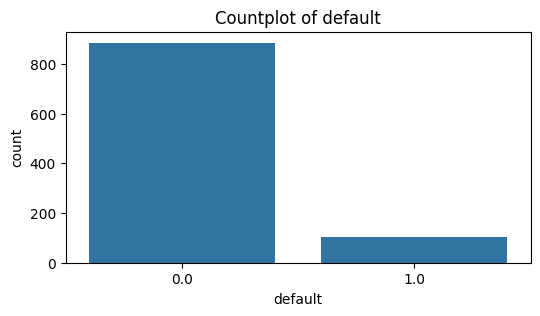

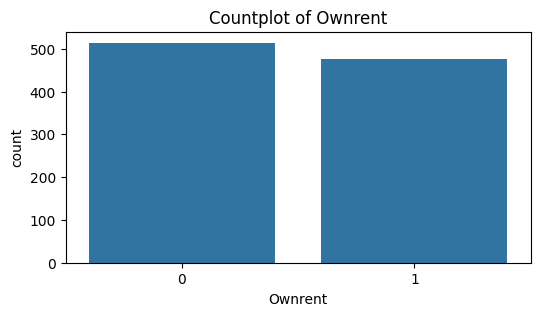

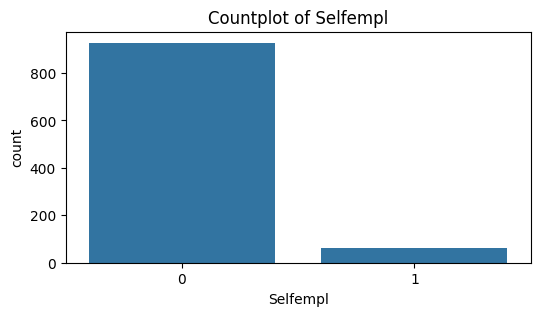

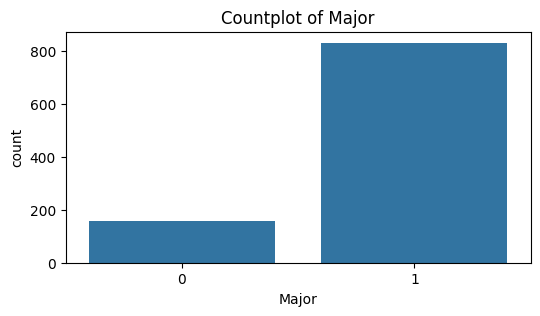

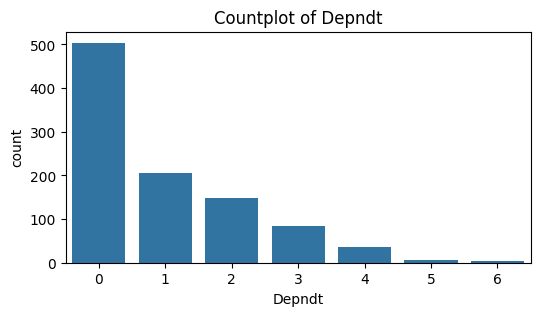

In [14]:
# Countplot for binary and ordinal variables
col_binarias_ordinales = ['default', 'Ownrent', 'Selfempl', 'Major', 'Depndt']

for col in col_binarias_ordinales:
    plt.figure(figsize=(6,3))
    sns.countplot(x=col, data=df_aceptados)
    plt.title(f'Countplot of {col}')
    plt.show()

In [15]:
df_aceptados.columns

Index(['Cardhldr', 'default', 'Age', 'Income', 'Exp_Inc', 'Avgexp', 'Ownrent',
       'Selfempl', 'Depndt', 'Inc_per', 'Cur_add', 'Major', 'Active'],
      dtype='object')

In [16]:
df_aceptados.describe(include='all')

,Cardhldr,default,Age,Income,Exp_Inc,Avgexp,Ownrent,Selfempl,Depndt,Inc_per,Cur_add,Major,Active
count,989.0,989.000000,989.000000,989.000000,989.000000,989.000000,989.000000,989.000000,989.000000,989.000000,989.000000,989.000000,989.000000
mean,1.0,0.105157,33.353893,3.450120,0.088958,239.432141,0.480283,0.061678,0.971689,2.218283,54.670374,0.840243,7.262892
std,0.0,0.306910,9.936300,1.719808,0.100060,289.762844,0.499864,0.240692,1.249780,1.357065,64.714763,0.366566,6.081568
min,1.0,0.000000,18.166670,0.210000,0.000186,0.000000,0.000000,0.000000,0.000000,0.070000,0.000000,0.000000,0.000000
25%,1.0,0.000000,25.333330,2.311500,0.026740,66.300830,0.000000,0.000000,0.000000,1.250000,12.000000,1.000000,2.000000
50%,1.0,0.000000,31.083330,3.000000,0.059872,149.700000,0.000000,0.000000,0.000000,1.975000,28.000000,1.000000,6.000000
75%,1.0,0.000000,39.750000,4.000000,0.113960,315.201700,1.000000,0.000000,2.000000,2.800000,72.000000,1.000000,11.000000
max,1.0,1.000000,83.500000,13.500000,0.906320,3099.505000,1.000000,1.000000,6.000000,10.999900,540.000000,1.000000,31.000000


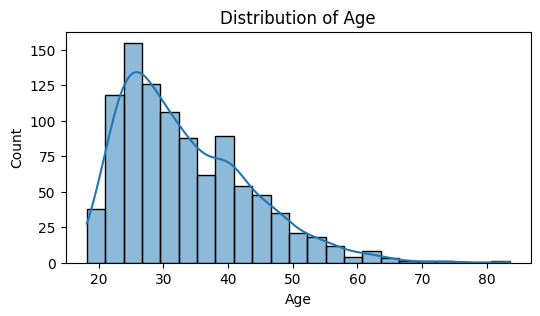

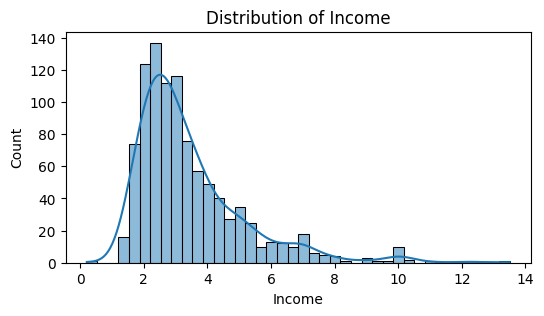

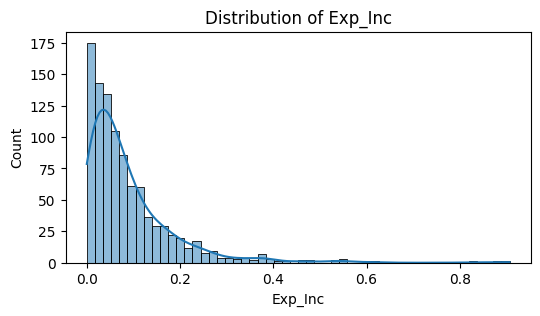

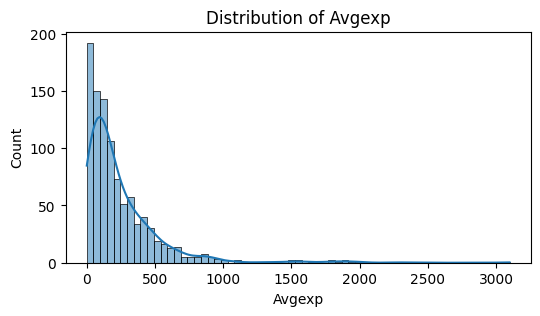

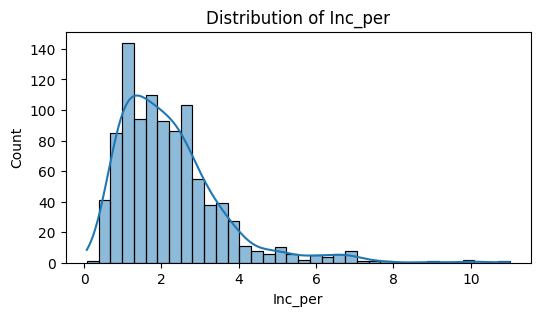

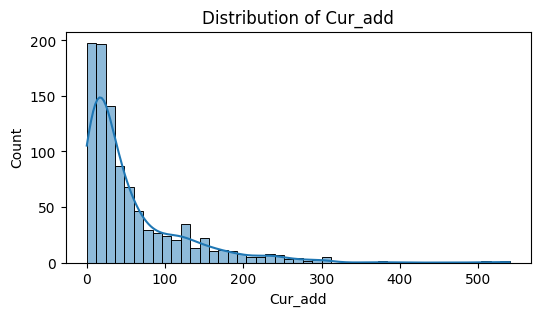

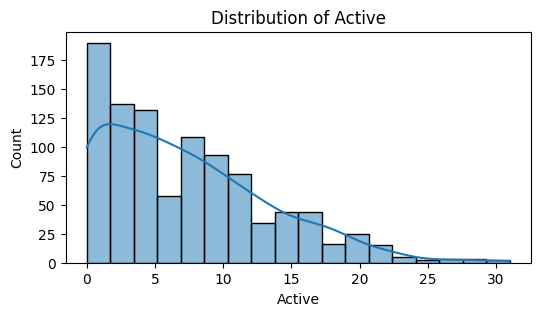

In [17]:
# Distribution of the continuous variables
col_continuas = ['Age', 'Income', 'Exp_Inc', 'Avgexp', 'Inc_per', 'Cur_add', 'Active']
for col in col_continuas:
    plt.figure(figsize=(6,3))
    sns.histplot(df_aceptados[col], kde=True)
    plt.title(f'Distribution of {col}')
    plt.show()

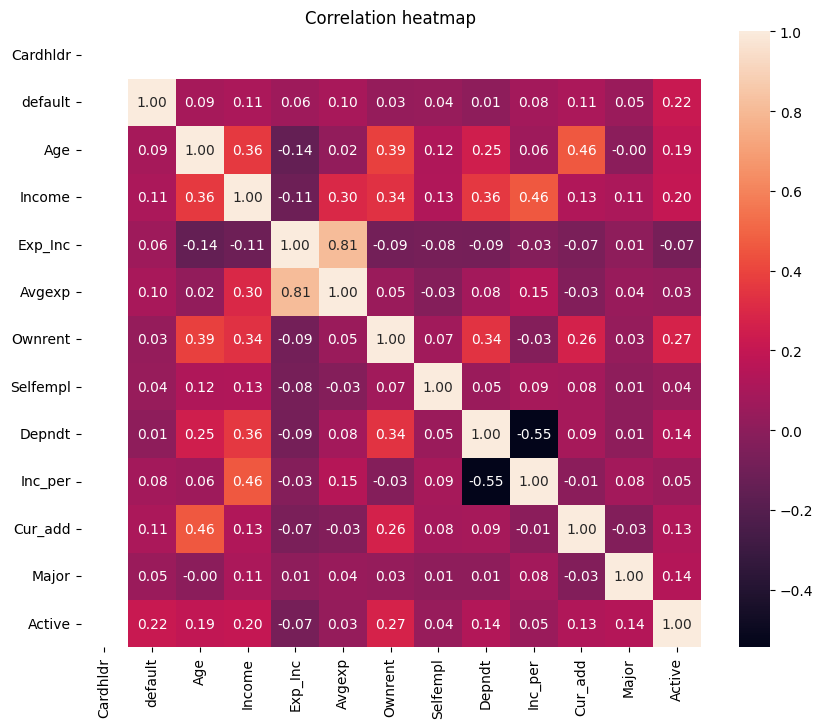

In [18]:
# Correlation heatmap
plt.figure(figsize=(10,8))
sns.heatmap(df_aceptados.corr(), annot=True, fmt=".2f")
plt.title('Correlation heatmap')
plt.show()

### Association Tests with the Target Variable (Chi-square)

In [19]:
def tests(df, col, normalize=False):
    """
    Function that builds a frequency table for a categorical variable
    and tests its association with the target variable via a Chi-square test.
    """
    print("="*50)
    print(f"Frequency table for variable {col}:")
    # Table for display (with margins and normalized if requested)
    ctabla_display = pd.crosstab(df[col], df['default'], margins=False, normalize=normalize).round(3)
    # Table for the test: absolute frequencies WITHOUT margins
    ctabla_test = pd.crosstab(df[col], df['default'])
    c, p, dof, expected = chi2_contingency(ctabla_test)
    print(ctabla_display)
    print(f"P_value: {p}")
    if p < 0.05:
        print(f"There is an association between column {col} and the target variable")
    else:
        print(f"There is no association between column {col} and the target variable")
    print("="*50)

In [20]:
df_aceptados.columns

Index(['Cardhldr', 'default', 'Age', 'Income', 'Exp_Inc', 'Avgexp', 'Ownrent',
       'Selfempl', 'Depndt', 'Inc_per', 'Cur_add', 'Major', 'Active'],
      dtype='object')

In [21]:
variables_binarias_ordinales = ['Ownrent', 'Selfempl', 'Major', 'Depndt']
for col in variables_binarias_ordinales:
    tests(df_aceptados, col, normalize=False)

Frequency table for variable Ownrent:


default  0.0  1.0
Ownrent          
0        465   49
1        420   55
P_value: 0.3450916187044496
There is no association between column Ownrent and the target variable
Frequency table for variable Selfempl:
default   0.0  1.0
Selfempl          
0         833   95
1          52    9
P_value: 0.3688674365639909
There is no association between column Selfempl and the target variable
Frequency table for variable Major:
default  0.0  1.0
Major            
0        147   11
1        738   93
P_value: 0.14786518918143896
There is no association between column Major and the target variable
Frequency table for variable Depndt:
default  0.0  1.0
Depndt           
0        451   53
1        184   21
2        134   14
3         73   12
4         33    2
5          6    1
6          4    1
P_value: 0.8329309819944027
There is no association between column Depndt and the target variable


In [22]:
df_aceptados['Depndt_cat'] = df_aceptados['Depndt'].apply(lambda x: '<=3' if x <=3 else '>3')

In [23]:
tests(df_aceptados, 'Depndt_cat', normalize=False)

Frequency table for variable Depndt_cat:
default     0.0  1.0
Depndt_cat          
<=3         842  100
>3           43    4
P_value: 0.8293518853923691
There is no association between column Depndt_cat and the target variable


In [24]:
df_aceptados.drop(columns=['Depndt_cat'], inplace=True)

### Variable Transformations (Skewness Correction)

Several continuous variables are strongly right-skewed. We compare the KDE of the raw variable
against a transformed version (square root or log) split by `default`, and keep the
transformation whenever it makes the separation between good and bad clients clearer.

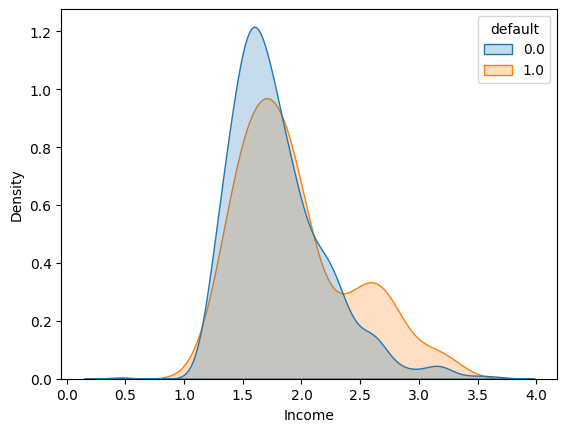

In [25]:
sns.kdeplot(data=df_aceptados, x= np.sqrt(df_aceptados['Income']),hue=df_aceptados['default'], shade=True,  common_norm=False)
plt.show()

In [26]:
df_aceptados['Income'] = np.sqrt(df_aceptados['Income'])
df_rechazados['Income'] = np.sqrt(df_rechazados['Income'])
df_nuevos['Income'] = np.sqrt(df_nuevos['Income'])

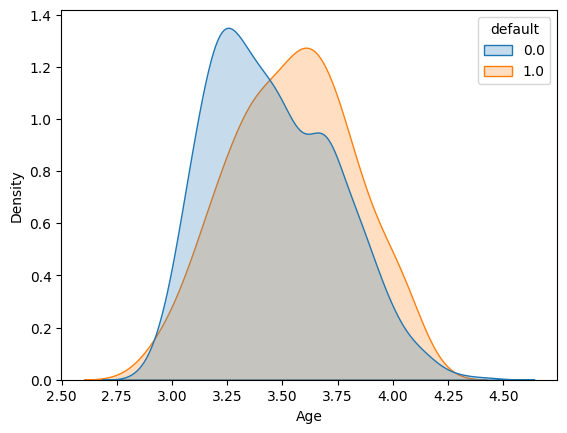

In [27]:
sns.kdeplot(data=df_aceptados, x= np.log(df_aceptados['Age']), hue=df_aceptados['default'],shade=True, common_norm=False)
plt.show()

In [28]:
df_aceptados['Age'] = np.log(df_aceptados['Age'])
df_rechazados['Age'] = np.log(df_rechazados['Age'])
df_nuevos['Age'] = np.log(df_nuevos['Age'])

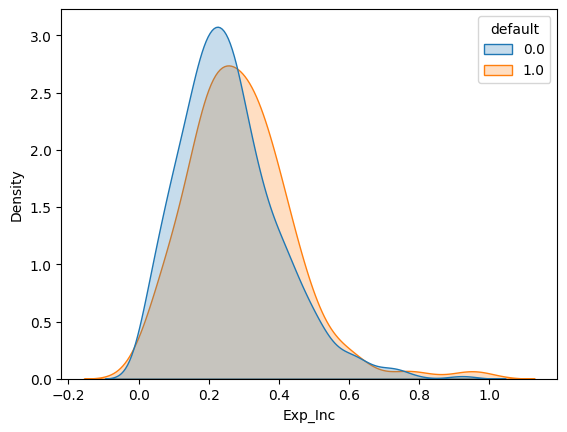

In [29]:
sns.kdeplot(data=df_aceptados, x= np.sqrt(df_aceptados['Exp_Inc']), hue=df_aceptados['default'],shade=True, common_norm=False)
plt.show()

In [30]:
df_aceptados['Exp_Inc'] = np.sqrt(df_aceptados['Exp_Inc'])
df_rechazados['Exp_Inc'] = np.sqrt(df_rechazados['Exp_Inc'])
df_nuevos['Exp_Inc'] = np.sqrt(df_nuevos['Exp_Inc'])

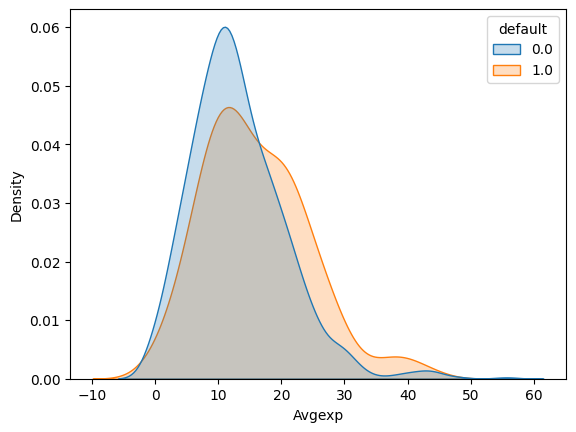

In [31]:
sns.kdeplot(data=df_aceptados, x= np.sqrt(df_aceptados['Avgexp']), hue=df_aceptados['default'],shade=True, common_norm=False)
plt.show()

In [32]:
df_aceptados['Avgexp'] = np.sqrt(df_aceptados['Avgexp'])
df_rechazados['Avgexp'] = np.sqrt(df_rechazados['Avgexp'])
df_nuevos['Avgexp'] = np.sqrt(df_nuevos['Avgexp'])

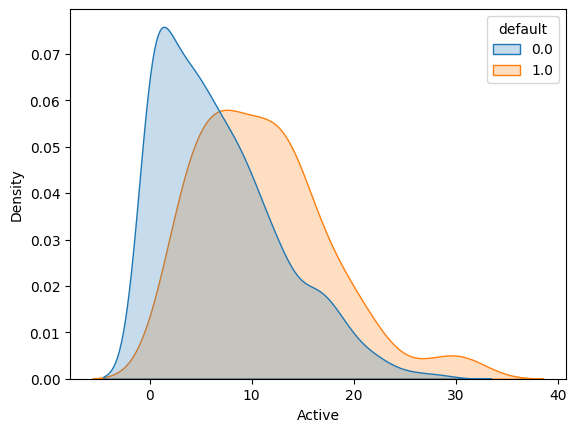

In [33]:
sns.kdeplot(data=df_aceptados, x= df_aceptados['Active'], hue=df_aceptados['default'],shade=True, common_norm=False)
plt.show()

In [34]:
df_aceptados.Active.describe()

count    989.000000
mean       7.262892
std        6.081568
min        0.000000
25%        2.000000
50%        6.000000
75%       11.000000
max       31.000000
Name: Active, dtype: float64

In [35]:
df_aceptados.drop(columns=["Avgexp"], inplace=True)
df_rechazados.drop(columns=["Avgexp"], inplace=True)
df_nuevos.drop(columns=["Avgexp"], inplace=True)

### Train/Test Split

In [36]:
df_train, df_test = train_test_split(df_aceptados,stratify=df_aceptados["default"], test_size=.25, random_state=321)

## Optimal Binning (WOE) Definition

In [37]:
df_train.head()

,Cardhldr,default,Age,Income,Exp_Inc,Ownrent,Selfempl,Depndt,Inc_per,Cur_add,Major,Active
1256,1.0,0.0,3.959225,1.549193,0.263220,0,1,1,1.200,96,1,2
9,1.0,1.0,3.381562,1.449138,0.268881,1,0,3,0.525,90,0,5
887,1.0,0.0,3.251666,1.870829,0.233435,0,0,0,3.500,34,0,2
603,1.0,1.0,2.944439,1.479865,0.583640,0,0,0,2.190,59,1,2
760,1.0,0.0,3.895216,1.303840,0.026568,0,0,1,0.850,14,0,6


In [38]:
def tramificacion_variable(df_train, variable):

    X=df_train[variable].values
    Y=df_train['default'].values
    optb = OptimalBinning(name=variable, dtype="numerical", solver="cp")

    # To fix the intervals manually (if the ones chosen by the algorithm are not desired), use:
    #                     user_splits=
    #                     user_splits_fixed=
    # Sometimes the data has missing values and special codes; in that case, to obtain a
    # separate category for those missing/special values, set:
    #                     special_codes = [-9, -8, -7]

    # Once defined, fit the binning
    optb.fit(X, Y)
    optb.splits
    binning_table = optb.binning_table

    return binning_table.build(),binning_table.iv.round(3), binning_table.gini.round(3),binning_table.js.round(3)

* If a variable's IV is below 0.02, the variable is considered non-predictive and should not be
  used in the model; if the IV is above 0.3, it is considered highly predictive
  (Siddiqi, 2006).

* The higher the Gini index, the greater the concentration of bad clients in some category of
  the variable, and therefore the more information that variable provides to separate good from
  bad clients. There is no fixed rule, but it is common to use a Gini index above 0.15 as the
  selection criterion (Siddiqi, 2006).

In [39]:
df_train.columns

Index(['Cardhldr', 'default', 'Age', 'Income', 'Exp_Inc', 'Ownrent',
       'Selfempl', 'Depndt', 'Inc_per', 'Cur_add', 'Major', 'Active'],
      dtype='object')

In [40]:
def tramificacion_varias(df_train, variables):
    """
    Function that bins several variables and displays their binning tables.
    """
    for variable in variables:
        print(f"Binning for variable {variable}:")
        tramificacion = tramificacion_variable(df_train, variable)

        display(tramificacion[0])
        print(f"IV: {tramificacion[1]}")
        print(f"Gini: {tramificacion[2]}")
        print(f"JS: {tramificacion[3]}")
        print("="*50)

In [41]:
tramificacion_varias(df_train, ['Age', 'Income', 'Exp_Inc', 'Ownrent','Selfempl', 'Depndt', 'Inc_per', 'Cur_add', 'Major', 'Active'])

Binning for variable Age:


,Bin,Count,Count (%),Non-event,Event,Event rate,WoE,IV,JS
0,"(-inf, 3.07)",44,0.059379,40,4,0.090909,0.162519,0.001471,0.000184
1,"[3.07, 3.19)",92,0.124157,86,6,0.065217,0.522522,0.027584,0.003409
2,"[3.19, 3.27)",95,0.128205,90,5,0.052632,0.750306,0.053755,0.006566
3,"[3.27, 3.34)",56,0.075574,55,1,0.017857,1.867267,0.130962,0.014342
4,"[3.34, 3.38)",39,0.052632,34,5,0.128205,-0.223144,0.002861,0.000357
5,"[3.38, 3.58)",163,0.219973,142,21,0.128834,-0.228762,0.012594,0.001571
6,"[3.58, inf)",252,0.340081,216,36,0.142857,-0.348307,0.047281,0.005880
7,Special,0,0.000000,0,0,0.000000,0.0,0.000000,0.000000
8,Missing,0,0.000000,0,0,0.000000,0.0,0.000000,0.000000
Totals,,741,1.000000,663,78,0.105263,,0.276508,0.032309


IV: 0.277
Gini: 0.237
JS: 0.032
Binning for variable Income:


,Bin,Count,Count (%),Non-event,Event,Event rate,WoE,IV,JS
0,"(-inf, 1.45)",120,0.161943,108,12,0.100000,0.057158,0.000517,0.000065
1,"[1.45, 1.48)",44,0.059379,40,4,0.090909,0.162519,0.001471,0.000184
2,"[1.48, 1.61)",111,0.149798,101,10,0.090090,0.172469,0.004162,0.000520
3,"[1.61, 1.66)",45,0.060729,43,2,0.044444,0.927987,0.036392,0.004392
4,"[1.66, 1.79)",114,0.153846,109,5,0.043860,0.941844,0.094468,0.011391
5,"[1.79, 2.41)",234,0.315789,208,26,0.111111,-0.060625,0.001189,0.000149
6,"[2.41, inf)",73,0.098516,54,19,0.260274,-1.095521,0.177630,0.021156
7,Special,0,0.000000,0,0,0.000000,0.0,0.000000,0.000000
8,Missing,0,0.000000,0,0,0.000000,0.0,0.000000,0.000000
Totals,,741,1.000000,663,78,0.105263,,0.315829,0.037856


IV: 0.316
Gini: 0.277
JS: 0.038
Binning for variable Exp_Inc:


...

IV: 0.233
Gini: 0.233
JS: 0.028
Binning for variable Major:


,Bin,Count,Count (%),Non-event,Event,Event rate,WoE,IV,JS
0,"(-inf, 0.50)",118,0.159244,111,7,0.059322,0.623554,0.048436,0.005958
1,"[0.50, inf)",623,0.840756,552,71,0.113965,-0.089198,0.006929,0.000866
2,Special,0,0.000000,0,0,0.000000,0.0,0.000000,0.000000
3,Missing,0,0.000000,0,0,0.000000,0.0,0.000000,0.000000
Totals,,741,1.000000,663,78,0.105263,,0.055365,0.006824


IV: 0.055
Gini: 0.078
JS: 0.007
Binning for variable Active:


,Bin,Count,Count (%),Non-event,Event,Event rate,WoE,IV,JS
0,"(-inf, 2.50)",198,0.267206,196,2,0.010101,2.444901,0.660086,0.066637
1,"[2.50, 7.50)",237,0.319838,213,24,0.101266,0.043172,0.000586,0.000073
2,"[7.50, 9.50)",79,0.106613,69,10,0.126582,-0.208545,0.005033,0.000628
3,"[9.50, 11.50)",58,0.078273,50,8,0.137931,-0.307485,0.008348,0.001039
4,"[11.50, 15.50)",84,0.113360,63,21,0.250000,-1.041454,0.181430,0.021706
5,"[15.50, inf)",85,0.114710,72,13,0.152941,-0.428349,0.024874,0.003086
6,Special,0,0.000000,0,0,0.000000,0.0,0.000000,0.000000
7,Missing,0,0.000000,0,0,0.000000,0.0,0.000000,0.000000
Totals,,741,1.000000,663,78,0.105263,,0.880357,0.093169


IV: 0.88
Gini: 0.412
JS: 0.093


In [42]:
df_train.Active.describe()

count    741.000000
mean       7.186235
std        6.044240
min        0.000000
25%        2.000000
50%        6.000000
75%       11.000000
max       31.000000
Name: Active, dtype: float64

The variables that provide the most information to separate bad from good clients are:
* Age
* Income
* Inc_per
* Cur_add
* Active

In [43]:
def tramificacion_variable(df_train, variable):

    X=df_train[variable].values
    Y=df_train['default'].values
    optb = OptimalBinning(name=variable, dtype="numerical", solver="cp")

    # To fix the intervals manually (if the ones chosen by the algorithm are not desired), use:
    #                     user_splits=
    #                     user_splits_fixed=
    # Sometimes the data has missing values and special codes; in that case, to obtain a
    # separate category for those missing/special values, set:
    #                     special_codes = [-9, -8, -7]

    # Once defined, fit the binning
    optb.fit(X, Y)
    optb.splits

    return optb

In [44]:
optb_age = tramificacion_variable(df_train, 'Age')
age_train_woe = optb_age.transform(df_train['Age'], metric="woe")

In [45]:
optb_income_train = tramificacion_variable(df_train, 'Income')
income_train_woe = optb_income_train.transform(df_train['Income'], metric="woe")
incper_train_woe = tramificacion_variable(df_train, 'Inc_per').transform(df_train['Inc_per'], metric="woe")
curadd_train_woe = tramificacion_variable(df_train, 'Cur_add').transform(df_train['Cur_add'], metric="woe")
active_train_woe = tramificacion_variable(df_train, 'Active').transform(df_train['Active'], metric="woe")

## Binning Process for the Full Feature Set

In [46]:
X = df_train.drop(columns=['default'])
y = df_train['default'].values
list_variables = X.columns.tolist()



# 2) Define the selection criteria
selection_criteria = {
    "iv": {"min": 0.02}  # we don't impose a "max": 1
}

# If the default parameters need to be changed for the binning of a specific variable, this
# can be done as a dictionary

binning_fit_params={
    "purpose":{"cat_cutoff": 0.10}
}

# 3) Define the binning process
binning_process = BinningProcess(
    min_bin_size=0.10,  # minimum size of each interval/category
    max_n_bins=5,       # maximum number of intervals/categories
    special_codes=None, # special codes, if any
    variable_names=list_variables,
    selection_criteria=selection_criteria,
    binning_fit_params=binning_fit_params,
    fixed_variables=None)

In [47]:
# 4) Obtain the optimal bins for all variables
df_train_binned = binning_process.fit(X, y)

In [48]:
df_train_binned.summary().sort_values('iv')

,name,dtype,status,selected,n_bins,iv,js,gini,quality_score
0,Cardhldr,numerical,OPTIMAL,False,1,0.0,0.0,0,0.0
5,Selfempl,numerical,OPTIMAL,False,1,0.0,0.0,0,0.0
6,Depndt,numerical,OPTIMAL,True,4,0.02381,0.002968,0.079688,0.005599
4,Ownrent,numerical,OPTIMAL,True,2,0.03123,0.003899,0.088235,0.074152
9,Major,numerical,OPTIMAL,True,2,0.055365,0.006824,0.077677,0.07534
3,Exp_Inc,numerical,OPTIMAL,True,4,0.07315,0.009083,0.145086,0.046359
7,Inc_per,numerical,OPTIMAL,True,5,0.169685,0.020596,0.203078,0.027171
8,Cur_add,numerical,OPTIMAL,True,5,0.194051,0.023883,0.22638,0.020987
2,Income,numerical,OPTIMAL,True,5,0.211863,0.025828,0.240515,0.070129
1,Age,numerical,OPTIMAL,True,4,0.235224,0.028551,0.230963,0.191523


In [49]:
# We can now transform the variables to WOE
df_train_woe=df_train_binned.transform(X, metric="woe")
df_train_woe.head()

,Age,Income,Exp_Inc,Ownrent,Depndt,Inc_per,Cur_add,Major,Active
1256,-0.348307,0.169636,0.554561,0.179517,0.100644,0.249530,-0.257335,-0.089198,2.444901
9,-0.227679,0.169636,-0.168514,-0.174419,-0.286175,0.204483,-0.257335,0.623554,0.043172
887,1.044908,-0.283768,0.554561,0.179517,-0.027638,-0.624939,-0.164003,0.623554,2.444901
603,0.393631,0.169636,-0.340402,0.179517,-0.027638,-0.033956,-0.257335,-0.089198,2.444901
760,-0.348307,0.057158,0.175764,0.179517,0.100644,0.204483,0.506896,0.623554,0.043172


In [50]:
df_train_woe.shape

(741, 9)

In [51]:
X_test = df_test.drop(columns=['default'])
y_test = df_test['default'].values

## 3. First Scorecard Model

Fit a logistic regression on the WOE-transformed variables and wrap it into a `Scorecard`
object, which converts predicted probabilities into a points-based credit score using the
PDO ("points to double the odds") scaling method.

In [52]:

# ============================================================
# FIRST MODEL ESTIMATION - Scorecard using Accepted applicants only
# ============================================================

# Scaling parameters: transform default probability into a credit score
# The optbinning library defines odd^B = (1-P)/P (inverse of the usual class convention),
# so the slope is positive: the better the odd^B, the higher the score
pdo_0 = 40               # every 40 score points doubles the odds
scorecard_points_0 = 600  # score assigned to an "excellent" reference client
odds_0_B = 50            # reference odds ratio B (equivalent to odds_0 = 1/50 of default)

estimator = LogisticRegression(solver="lbfgs", penalty="l2")

tarjeta = Scorecard(
    binning_process=binning_process,
    estimator=estimator,
    scaling_method="pdo_odds",
    scaling_method_params={"pdo": pdo_0, "odds": odds_0_B, "scorecard_points": scorecard_points_0}
)
tarjeta.fit(X, y, show_digits=4)
tarjeta.table().head(60)

,Variable,Bin,Points
0,Age,"(-inf, 3.1901)",69.025102
1,Age,"[3.1901, 3.3367)",92.191212
2,Age,"[3.3367, 3.5754)",46.924965
3,Age,"[3.5754, inf)",42.634196
4,Age,Special,55.023557
5,Age,Missing,55.023557
0,Income,"(-inf, 1.4457)",56.595047
1,Income,"[1.4457, 1.6078)",59.687471
2,Income,"[1.6078, 1.7874)",80.809916
3,Income,"[1.7874, 2.1920)",47.221749


Mean estimated probability on train: 0.1052 | Actual default rate: 0.1053


Cut-off point that maximizes F1: 0.19  |  Maximum F1-score: 0.369


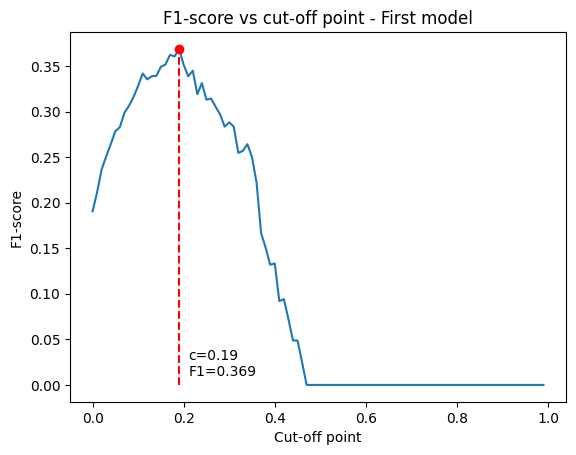

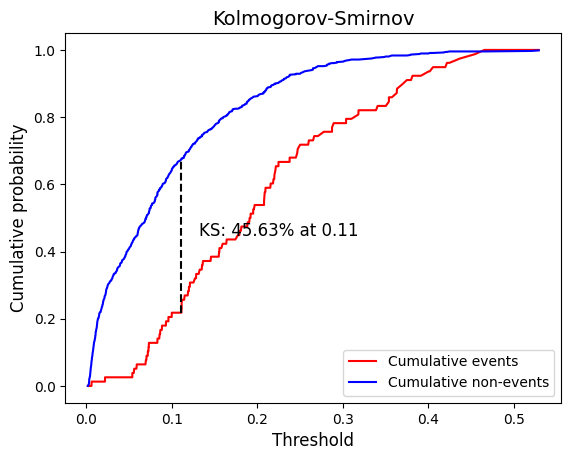

In [53]:

# Predicted default probability on the training sample
Y_pred = tarjeta.predict_proba(X)[:, 1]
print(f"Mean estimated probability on train: {Y_pred.mean():.4f} | Actual default rate: {y.mean():.4f}")

# Selection of the optimal cut-off point via F1-score
c = np.arange(0, 1, 0.01)
f1_scores = [f1_score(y, np.multiply(Y_pred > c_, 1)) for c_ in c]
c_maxF1 = c[np.argmax(f1_scores)]
print(f"Cut-off point that maximizes F1: {c_maxF1:.2f}  |  Maximum F1-score: {np.max(f1_scores):.3f}")

plt.plot(c, f1_scores)
plt.stem(c_maxF1, np.max(f1_scores), linefmt='r--', markerfmt='ro', basefmt='r--')
plt.title("F1-score vs cut-off point - First model")
plt.xlabel("Cut-off point")
plt.ylabel("F1-score")
plt.text(c_maxF1 + 0.02, 0.01, f"c={c_maxF1:.2f}\nF1={np.max(f1_scores):.3f}")
plt.show()

# KS plot: maximum distance between the cumulative distributions of good and bad clients
plot_ks(y, Y_pred)

In [54]:

# Final cut-off point: we use the observed mean default rate (conservative approach)
Prob_Corte = y.mean()

# Linear transformation probability -> score:
#   score = Offset - Factor * ln(odds_default)
#   with odds_default = P/(1-P)
Factor = pdo_0 / np.log(2)
Offset = scorecard_points_0 + Factor * np.log(1 / odds_0_B)

# Score equivalent to the probability cut-off point
Score_Corte = Offset - Factor * np.log(Prob_Corte / (1 - Prob_Corte))

print(f"Factor: {Factor:.2f}  |  Offset: {Offset:.2f}")
print(f"Prob_Corte: {Prob_Corte:.3f}  ->  Equivalent cut-off score: {Score_Corte:.2f}")
print(f"(For comparison, the optimal F1 cut-off was at: {c_maxF1:.2f})")

Factor: 57.71  |  Offset: 374.25
Prob_Corte: 0.105  ->  Equivalent cut-off score: 497.74
(For comparison, the optimal F1 cut-off was at: 0.19)


In [55]:

# Confusion matrix on the TRAINING sample (in-sample diagnostics)
df_train["Y_pronostico"] = np.multiply(Y_pred > Prob_Corte, 1)

# Overall accuracy (correct predictions over the total)
tab_all = pd.crosstab(df_train["default"], df_train["Y_pronostico"], margins=True, normalize="all").round(3)
print("Accuracy:\n", tab_all)
print(f"Overall accuracy: {(tab_all.iloc[1,1] + tab_all.iloc[0,0]):.3f}")

# Recall: sensitivity (% of bad clients detected) and specificity (% of good clients detected)
tab_row = pd.crosstab(df_train["default"], df_train["Y_pronostico"], margins=True, normalize=0).round(3)
print(f"\nSensitivity (% of bad clients correctly identified): {tab_row.iloc[1,1]:.3f}")
print(f"Specificity (% of good clients correctly identified): {tab_row.iloc[0,0]:.3f}")
print(f"F1-score train: {f1_score(df_train['default'], df_train['Y_pronostico']):.3f}")

Accuracy:
 Y_pronostico      0      1    All
default                          
0.0           0.590  0.305  0.895
1.0           0.023  0.082  0.105
All           0.613  0.387  1.000
Overall accuracy: 0.672

Sensitivity (% of bad clients correctly identified): 0.782
Specificity (% of good clients correctly identified): 0.659
F1-score train: 0.334


Test accuracy:
 Y_pronostico      0      1    All
default                          
0.0           0.516  0.379  0.895
1.0           0.028  0.077  0.105
All           0.544  0.456  1.000
Overall test accuracy: 0.593
Test sensitivity: 0.731  |  Test specificity: 0.577
Test F1-score: 0.273


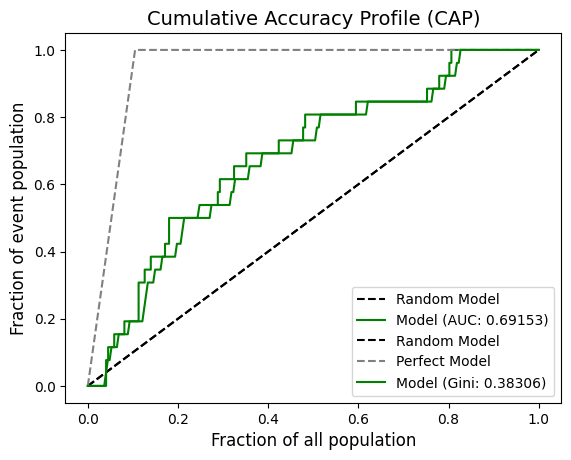

In [56]:

# ---- OUT-OF-SAMPLE DIAGNOSTICS: TEST set ----
# Real model diagnostics are always done on data NOT used for training
Y_test_pred = tarjeta.predict_proba(X_test)[:, 1]

# ROC curve (AUC): area under the curve — the closer to 1, the better it separates good from bad
plot_auc_roc(y_test, Y_test_pred)

# CAP curve (Cumulative Accuracy Profile): compares the model against random selection
plot_cap(y_test, Y_test_pred)

# Confusion matrix on the test set
df_test["Y_pronostico"] = np.multiply(Y_test_pred > Prob_Corte, 1)
tab_test = pd.crosstab(df_test["default"], df_test["Y_pronostico"], margins=True, normalize="all").round(3)
print("Test accuracy:\n", tab_test)
print(f"Overall test accuracy: {(tab_test.iloc[1,1] + tab_test.iloc[0,0]):.3f}")
tab_row_test = pd.crosstab(df_test["default"], df_test["Y_pronostico"], margins=True, normalize=0).round(3)
print(f"Test sensitivity: {tab_row_test.iloc[1,1]:.3f}  |  Test specificity: {tab_row_test.iloc[0,0]:.3f}")
print(f"Test F1-score: {f1_score(df_test['default'], df_test['Y_pronostico']):.3f}")

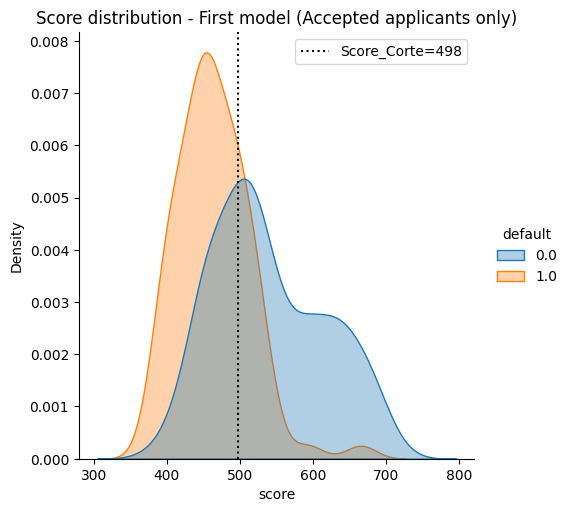

In [57]:

# Score distribution: visual separation between good (default=0) and bad (default=1) clients
score = tarjeta.score(X)
datos_score = pd.DataFrame({"score": score, "default": y})

sns.displot(data=datos_score, x="score", hue="default", kind="kde", fill=True, alpha=0.35, common_norm=False)
plt.axvline(Score_Corte, color='k', linestyle=":", label=f"Score_Corte={Score_Corte:.0f}")
plt.title("Score distribution - First model (Accepted applicants only)")
plt.legend()
plt.show()

# Stage 2: Reject Inference (Hard Cut-off Augmentation)

The first model above only "sees" applicants who already passed a previous approval filter, so
it likely underestimates the true default risk of the general applicant population. To correct
for this **sample selection bias**, we infer the outcome of rejected applicants by scoring them
with the first model and applying a hard cut-off: if their estimated probability of default is
above `Prob_Corte`, we label them as `default = 1`.

We then re-estimate the scorecard on the combined sample (accepted, with observed default, plus
rejected, with inferred default), which should better represent the full population of
applicants.

In [58]:

# The rejected applicants have no observed 'default' variable, since they never received a card.
# We infer their behaviour by scoring them with the first model:
#   -> if the estimated probability > Prob_Corte, we assign default = 1

# The transformations (Income sqrt, Age log, Exp_Inc sqrt, drop Avgexp) were already applied
# to df_rechazados in the previous steps, so we can use the dataframe directly

X_rechazados = df_rechazados.drop(columns=['default'])  # default is NaN for rejected applicants
Y_rechazados_pred = tarjeta.predict_proba(X_rechazados)[:, 1]

df_rechazados = df_rechazados.copy()
df_rechazados["default"] = np.multiply(Y_rechazados_pred > Prob_Corte, 1)

print("Inferred default distribution among rejected applicants:")
print(df_rechazados["default"].value_counts(normalize=True).round(3))

# Also store the first model's prediction for the new applicants,
# to compare later against the second model
X_nuevos_tmp = df_nuevos.drop(columns=['default'])
Y_nuevos_pred_1 = tarjeta.predict_proba(X_nuevos_tmp)[:, 1]
df_nuevos = df_nuevos.copy()
df_nuevos["Prob_SinRechazados"] = Y_nuevos_pred_1
df_nuevos["y_SinRechazados"] = np.multiply(Y_nuevos_pred_1 > Prob_Corte, 1)

# Concatenate accepted (observed default) + rejected (inferred default)
# This combined sample is representative of ALL applicants, removing the selection bias
df_completo = pd.concat([df_aceptados, df_rechazados], axis=0).reset_index(drop=True)
print(f"\nTotal records (Accepted + Inferred rejected): {len(df_completo)}")
print("Default distribution in the combined sample:")
print(df_completo["default"].value_counts(normalize=True).round(3))

Inferred default distribution among rejected applicants:
default
0    0.725
1    0.275
Name: proportion, dtype: float64

Total records (Accepted + Inferred rejected): 1280
Default distribution in the combined sample:
default
0.0    0.856
1.0    0.144
Name: proportion, dtype: float64


In [59]:

# ---- Train/test split of the combined sample and a new BinningProcess ----

df_train2, df_test2 = train_test_split(
    df_completo, stratify=df_completo["default"], test_size=0.25, random_state=12345
)
print(f"Train: {len(df_train2)} records | Default rate: {df_train2['default'].mean():.3f}")
print(f"Test:  {len(df_test2)}  records | Default rate: {df_test2['default'].mean():.3f}")

# Exclude 'Cardhldr': in the combined sample it equals 1 (accepted) or 0 (rejected),
# which would introduce data leakage (it is the historical selection criterion, not a client feature)
X2 = df_train2.drop(columns=['default', 'Cardhldr'])
y2 = df_train2['default'].values
list_variables2 = X2.columns.tolist()

selection_criteria2 = {"iv": {"min": 0.02}}

binning_process2 = BinningProcess(
    min_bin_size=0.10,
    max_n_bins=5,
    variable_names=list_variables2,
    selection_criteria=selection_criteria2
)
df_train2_binned = binning_process2.fit(X2, y2)

# IV summary per variable: variables with IV >= 0.02 enter the model
df_train2_binned.summary().sort_values('iv', ascending=False)

Train: 960 records | Default rate: 0.144
Test:  320  records | Default rate: 0.144


,name,dtype,status,selected,n_bins,iv,js,gini,quality_score
9,Active,numerical,OPTIMAL,True,5,1.258738,0.12971,0.508269,0.012843
0,Age,numerical,OPTIMAL,True,4,0.489362,0.057401,0.331694,0.642829
2,Exp_Inc,numerical,OPTIMAL,True,5,0.4228,0.050736,0.343797,0.321678
7,Cur_add,numerical,OPTIMAL,True,5,0.32299,0.039099,0.270567,0.064442
1,Income,numerical,OPTIMAL,True,3,0.208586,0.025185,0.219542,0.558824
6,Inc_per,numerical,OPTIMAL,True,5,0.090074,0.011087,0.146461,0.073455
5,Depndt,numerical,OPTIMAL,True,4,0.026216,0.003262,0.071018,0.000874
3,Ownrent,numerical,OPTIMAL,False,2,0.017363,0.002169,0.065693,0.040404
8,Major,numerical,OPTIMAL,False,2,0.009708,0.001211,0.036338,0.010953
4,Selfempl,numerical,OPTIMAL,False,1,0.0,0.0,0,0.0


In [60]:

# Estimation of the second Scorecard on the combined sample (free of sample selection bias)
estimator2 = LogisticRegression(solver="lbfgs", penalty="l2")

tarjeta2 = Scorecard(
    binning_process=binning_process2,
    estimator=estimator2,
    scaling_method="pdo_odds",
    scaling_method_params={"pdo": pdo_0, "odds": odds_0_B, "scorecard_points": scorecard_points_0}
)
tarjeta2.fit(X2, y2, show_digits=4)
tarjeta2.table().head(60)

,Variable,Bin,Points
0,Age,"(-inf, 3.1658)",99.838133
1,Age,"[3.1658, 3.3127)",125.196370
2,Age,"[3.3127, 3.5373)",65.318294
3,Age,"[3.5373, inf)",49.041885
4,Age,Special,67.764707
5,Age,Missing,67.764707
0,Income,"(-inf, 1.6658)",73.968411
1,Income,"[1.6658, 1.7877)",104.009629
2,Income,"[1.7877, inf)",56.058623
3,Income,Special,67.764707


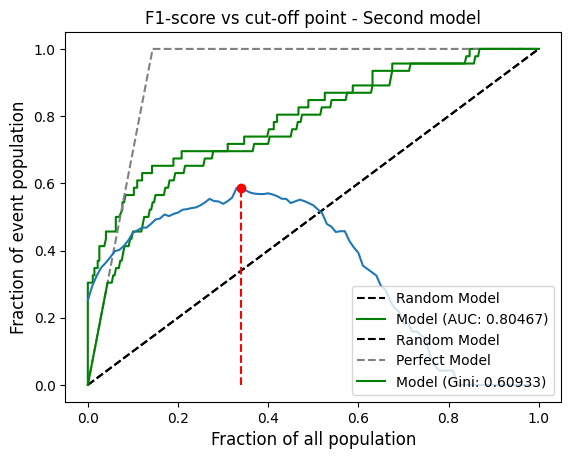

Prob_Corte2: 0.340  ->  Score_Corte2: 412.52


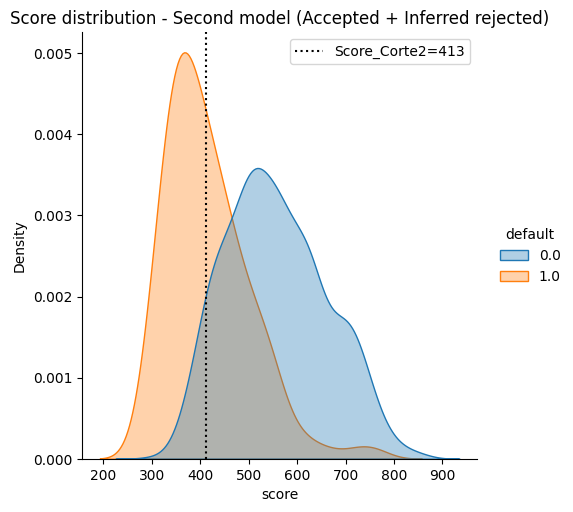

In [61]:

# Out-of-sample diagnostics for the second model (test set of the combined sample)
X_test2 = df_test2.drop(columns=['default', 'Cardhldr'])
y_test2 = df_test2['default'].values

Y_pred2 = tarjeta2.predict_proba(X2)[:, 1]
Y_test2_pred = tarjeta2.predict_proba(X_test2)[:, 1]

plot_auc_roc(y_test2, Y_test2_pred)
plot_cap(y_test2, Y_test2_pred)

# Cut-off point for the second model via F1-score
c = np.arange(0, 1, 0.01)
f1_scores2 = [f1_score(y2, np.multiply(Y_pred2 > c_, 1)) for c_ in c]
c_maxF1_2 = c[np.argmax(f1_scores2)]

plt.plot(c, f1_scores2)
plt.stem(c_maxF1_2, np.max(f1_scores2), linefmt='r--', markerfmt='ro', basefmt='r--')
plt.title("F1-score vs cut-off point - Second model")
plt.show()

# We use the optimal F1 as the cut-off point for the second model
Prob_Corte2 = c_maxF1_2
Score_Corte2 = Offset - Factor * np.log(Prob_Corte2 / (1 - Prob_Corte2))
print(f"Prob_Corte2: {Prob_Corte2:.3f}  ->  Score_Corte2: {Score_Corte2:.2f}")

# Score distribution for the second model
score2 = tarjeta2.score(X2)
datos_score2 = pd.DataFrame({"score": score2, "default": y2})
sns.displot(data=datos_score2, x="score", hue="default", kind="kde", fill=True, alpha=0.35, common_norm=False)
plt.axvline(Score_Corte2, color='k', linestyle=":", label=f"Score_Corte2={Score_Corte2:.0f}")
plt.title("Score distribution - Second model (Accepted + Inferred rejected)")
plt.legend()
plt.show()

# Stage 3: Scoring the New Applications

We now have the final model (`tarjeta2`), estimated on the combined sample (Accepted + Inferred
rejected) and therefore free of sample selection bias. We use it to score the 34 new applicants
(`df_nuevos`, `Cardhldr = NaN`) and decide whether to grant them a card.

As a reference, in Stage 2 we already computed the default probability of these same clients
using the **first model** (biased, Accepted only): `df_nuevos["Prob_SinRechazados"]` and
`df_nuevos["y_SinRechazados"]`. We now obtain the equivalent score with the corrected model.

In [62]:
# Score the new clients with the final model (tarjeta2)
# Exclude the columns that are not explanatory variables of tarjeta2:
#   - 'default' and 'Cardhldr': don't exist / don't apply for new applicants
#   - 'Prob_SinRechazados', 'y_SinRechazados': outputs of the first model, not inputs
X_nuevos = df_nuevos.drop(columns=['default', 'Cardhldr', 'Prob_SinRechazados', 'y_SinRechazados'])

Y_nuevos_pred_2 = tarjeta2.predict_proba(X_nuevos)[:, 1]

df_nuevos["Prob_ConRechazados"] = Y_nuevos_pred_2
df_nuevos["y_ConRechazados"] = np.multiply(Y_nuevos_pred_2 > Prob_Corte2, 1)

print("Distribution of decisions for the new applicants (final model):")
print(df_nuevos["y_ConRechazados"].value_counts(normalize=True).round(3))

Distribution of decisions for the new applicants (final model):
y_ConRechazados
1    0.529
0    0.471
Name: proportion, dtype: float64


In [63]:
print("Mean estimated default probability (first model, WITHOUT correcting for reject bias):",
      df_nuevos["Prob_SinRechazados"].mean().round(3))
print("Mean estimated default probability (final model, WITH reject inference):            ",
      df_nuevos["Prob_ConRechazados"].mean().round(3))

Mean estimated default probability (first model, WITHOUT correcting for reject bias): 0.095
Mean estimated default probability (final model, WITH reject inference):             0.345


If the mean probability under the final model is higher than under the first model, this
confirms that ignoring the rejected applicants led to underestimating the real default risk of
the new applicants (the biased model only "saw" the behaviour of clients who had already passed
an approval filter).

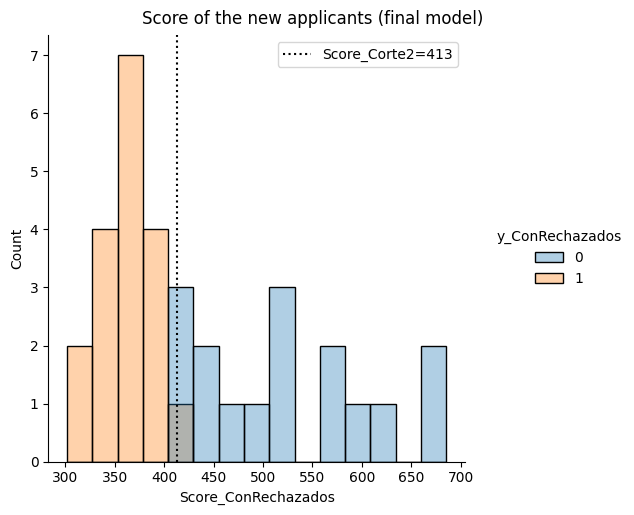

In [64]:
# We also compute the score of the new applicants with the final model
df_nuevos["Score_ConRechazados"] = tarjeta2.score(X_nuevos)

g = sns.displot(data=df_nuevos, x="Score_ConRechazados",
    hue="y_ConRechazados", kind="hist", bins=15,
    fill=True, alpha=0.35, common_norm=True)
g.fig.suptitle("Score of the new applicants (final model)", y=1.02)
plt.axvline(Score_Corte2, color='k', linestyle=":", label=f"Score_Corte2={Score_Corte2:.0f}")
plt.legend()
plt.show()

In [65]:
# Final decision table for the 34 new applicants
df_nuevos["Decision"] = np.where(df_nuevos["y_ConRechazados"] == 1, "Deny", "Grant")

resumen_nuevos = df_nuevos[[
    "Prob_SinRechazados", "Prob_ConRechazados",
    "Score_ConRechazados", "Decision"
]].round(3).sort_values("Score_ConRechazados")

print(f"Final model cut-off -> Prob_Corte2: {Prob_Corte2:.3f} | Score_Corte2: {Score_Corte2:.2f}\n")
print(resumen_nuevos["Decision"].value_counts())
resumen_nuevos

Final model cut-off -> Prob_Corte2: 0.340 | Score_Corte2: 412.52

Decision
Deny     18
Grant    16
Name: count, dtype: int64


,Prob_SinRechazados,Prob_ConRechazados,Score_ConRechazados,Decision
1294,0.307,0.778,301.820,Deny
1292,0.193,0.771,304.250,Deny
1310,0.190,0.636,342.023,Deny
1289,0.266,0.628,343.941,Deny
1311,0.178,0.605,349.655,Deny
1286,0.137,0.600,350.825,Deny
1296,0.102,0.578,356.058,Deny
1303,0.145,0.573,357.327,Deny
1287,0.191,0.564,359.424,Deny
1314,0.107,0.516,370.475,Deny
